# Using the `SigmaA` Class

The surface density with respect to semi-major axis, $\Sigma(a)$ is defined through the `SigmaA` class. This class must be initialised for the pipeline, and is directly used when computing the final $\bar\Sigma(r)$ profile. 

The class comes with a host of pre-built $\Sigma(a)$ profiles but also supports any supplied functional form. This page demonstrates all of the built in functionalities within the class.

## Getting Started: Class Functionality

To begin using the class, the user must first initialise it by specifying the following:

- The minimum and maximum semi-major axes, set via the `a_min` and `a_max` arguments (these define the truncation bounds)
- The overall amplitude or normalisation factor, specified using `sigma0`
- The desired profile type, selected through the `profile_type` argument

In addition to these required parameters, each built-in profile type accepts its own specific keyword arguments, which must also be supplied at initialisation. These profile-specific arguments are summarised in the table below and explained in more detail in the following sections:

| Profile Type      | Required Parameters            |
|-------------------|--------------------------------|
| `'power_law'`     | `power`                        |
| `'gaussian'`      | `gauss_width`, `gauss_center`  |
| `'step_up'`       | `step`                         |
| `'step_down'`     | `step`                         |
| `'custom'`        | `custom_func` (callable)       |

### Initialising the Class

This is an example on how to initialise the class with a power-law profile. Each built-in profile has its own arguments that must be defined. See the next sections for demonstrations with the other built-in profiles. In the case of the power-law, the user must define the `power` parameter.

In [1]:
# First import the class
from debrispy import SigmaA
import numpy as np

# Initialise
sigma_a_profile = SigmaA(a_min=1, a_max=4, profile_type='power_law', sigma0=1, power=0.5)

### Getting Information about the Class via Print

Once initialised, the user can get check information about the class parameters, such as the profile type and semi-major axis range, by simply printing the class.

In [2]:
print(sigma_a_profile)

SigmaA(type=power_law, a_min=1, a_max=4, sigma0=1, power=0.5)


### Calculating and Returning the $\Sigma(a)$ Values

Once initialised, the user can obtain the $\Sigma(a)$ values for a chosen array of $a$ values by using the `get_values` method or by simply calling the class as a function, which internally uses the same method.

In [3]:
# Define the a values to calculate the profile over
a_vals = np.linspace(0.01, 4, 5)

# Option 1: Return the values through the 'get_values' method
sigma_a_vals = sigma_a_profile.get_values(a_vals)

# Option 2: Return the values by calling the initialised class directly
sigma_a_vals = sigma_a_profile(a_vals)

print(sigma_a_vals)

[0.         0.99627096 0.70622455 0.57710986 0.5       ]


### Visualising the Profile

The `Sigma(a)` class also a plotting tool, which can be called through the `plot` method. This method has a host of arguments to change appearance of the plot, and also has support for any `plt.plot` keyword arguments (e.g. `linewidth`, `linestyle`), which the method automatically applies.

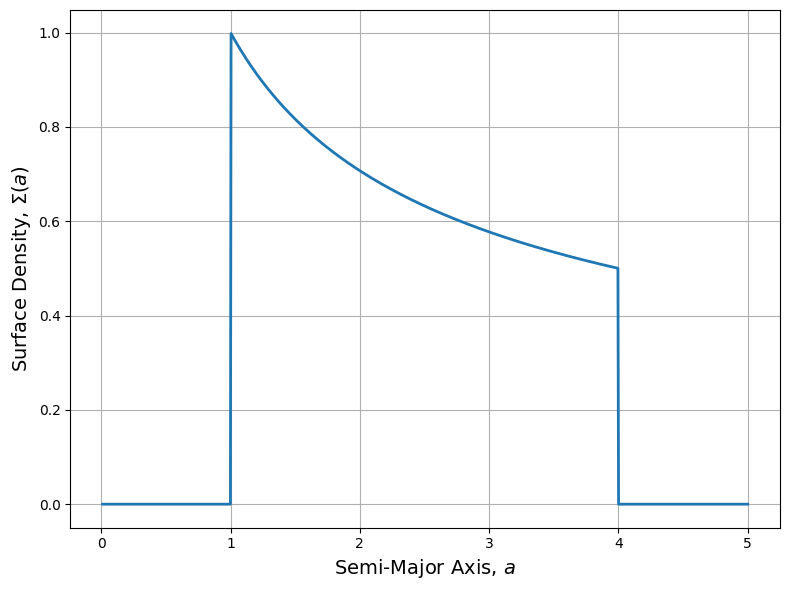

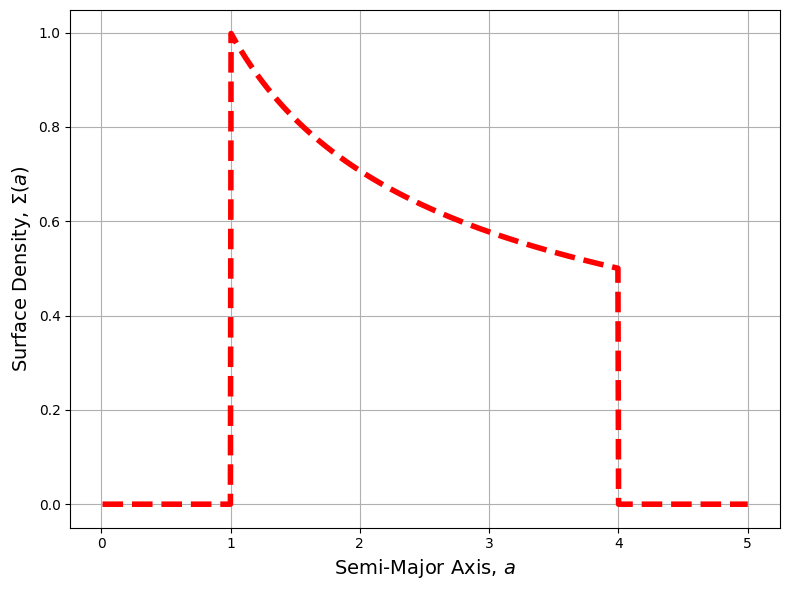

In [4]:
a_vals = np.linspace(0.01, 5, 1_000)

sigma_a_profile.plot(a_vals = a_vals, save=False, show = True, 
                     filename = "figures/sigma_a.png", figsize = (8, 6))

sigma_a_profile.plot(a_vals = a_vals, save=False, show = True, 
                     filename = "figures/sigma_a.png", figsize = (8, 6), 
                     linestyle = "--", linewidth = 4, color = 'red')

### Calculating the Area

After initialisation, the user can calculate the area of the curve via the `get_area` method. This uses the adaptive quadrature through `scipy.integrate.quad` internally.

In [5]:
area_value = sigma_a_profile.compute_area()
print(f"The area is: {area_value}")

The area is: 2.0


## Built-In Profile Types

### Power-Law Profile

The power-law profile is called using the `profile_type = 'power_law'` argument, and is defined as, 

$$
\Sigma(a) = \Sigma_0 \left(  \frac{a_\text{min}}{a} \right)^p,
$$

where $\Sigma_0$ is set using the `sigma0` argument, and $p$ is set using the `power` argument

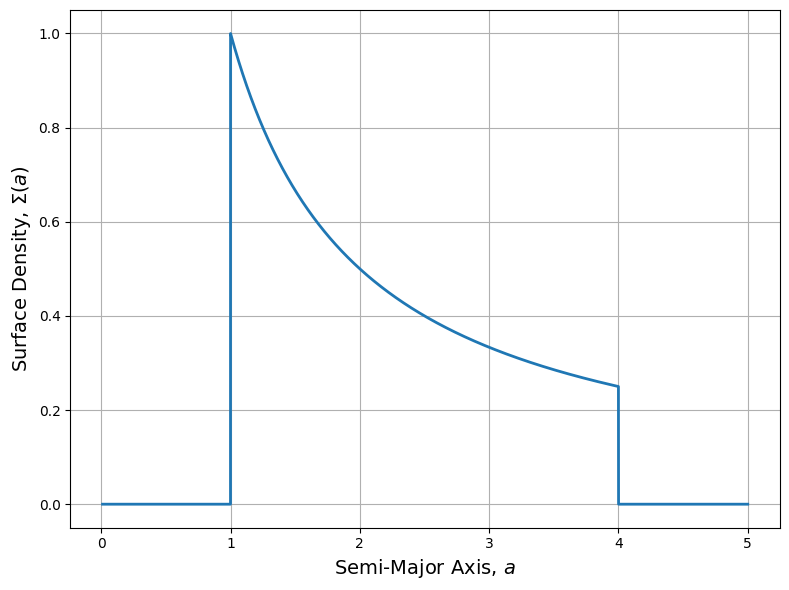

Area: 1.386


In [6]:
power_law_profile = SigmaA(a_min=1, a_max=4, profile_type='power_law', sigma0=1, power=1)

a_vals = np.linspace(0.01, 5, 10000)
power_law_profile.plot(a_vals)

print(f"Area: {power_law_profile.compute_area():.3f}")

### Gaussian Profile

The Gaussian profile is called using the `profile_type = 'gaussian'` argument and is defines as,

$$
    \Sigma(a) = \frac{\Sigma_0}{\sqrt{2\pi}\sigma} \exp{\left[ -\frac{(a - a_0)^2}{2\sigma^2} \right]},
$$

where $\Sigma_0$ is set using the `sigma0` argument, $\sigma$ is set using the `gauss_width` argument and $a_0$ is set with the `gauss_center` argument.

**Note**: Since the profile is properly normalised, `sigma0` also effectively sets the area under the curve.

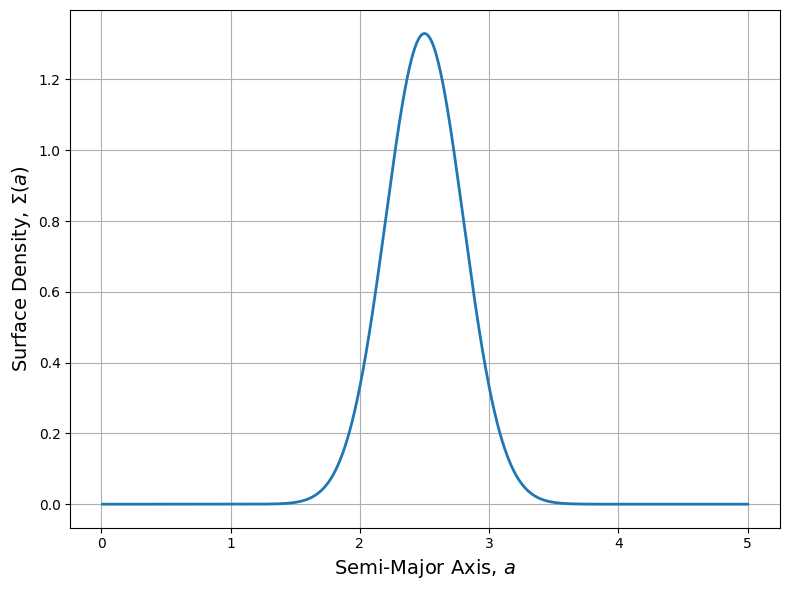

Area: 1.000


In [7]:
gaussian_profile = SigmaA(a_min=1, a_max=4, profile_type='gaussian', 
                          sigma0=1, gauss_center = 2.5, gauss_width = 0.3)
gaussian_profile.plot(a_vals)

print(f"Area: {gaussian_profile.compute_area():.3f}")

It is also possible to get truncated Gaussian profiles using this setup:

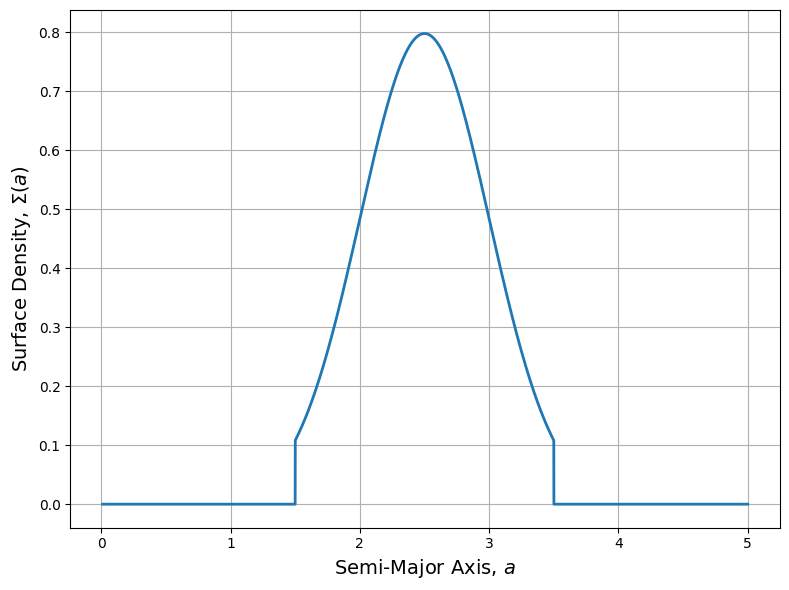

Area: 0.954


In [8]:
gaussian_profile_trunc = SigmaA(a_min=1.5, a_max=3.5, profile_type='gaussian', 
                                sigma0=1, gauss_center = 2.5, gauss_width = 0.5)
gaussian_profile_trunc.plot(a_vals)

print(f"Area: {gaussian_profile_trunc.compute_area():.3f}")

### Step-Function Profile

The step-function profiles are accesed by setting `profile_type = 'step_up'`, which is defined as, 

$$
    \Sigma(a) = \Sigma_0 \quad \text{for} \quad a > s
$$

 or `profile_type = 'step_down'`, which is defined as, 

$$
    \Sigma(a) = \Sigma_0 \quad \text{for} \quad a < s
$$

 In both cases, the position of the step, $s$, is defined via the `step` argument.

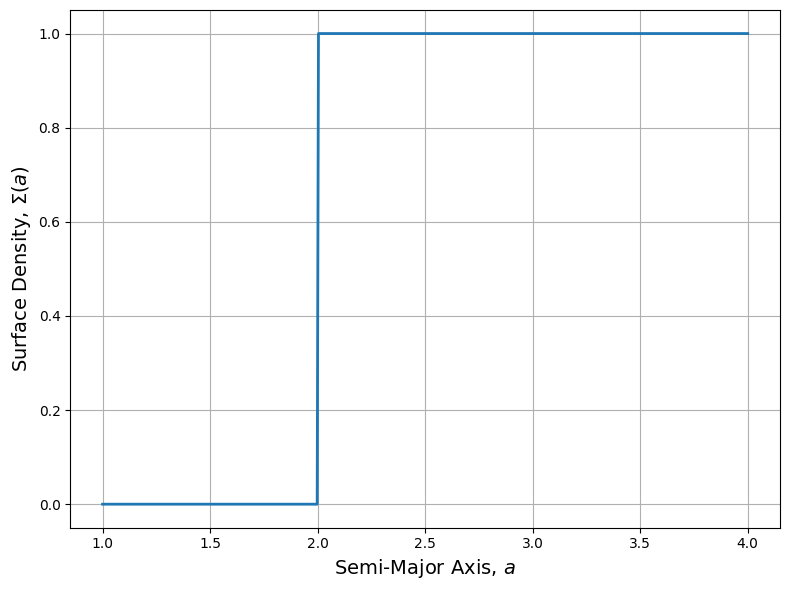

In [9]:
step_up_profile = SigmaA(a_min=1, a_max=4, profile_type='step_up', step=2)
step_up_profile.plot()

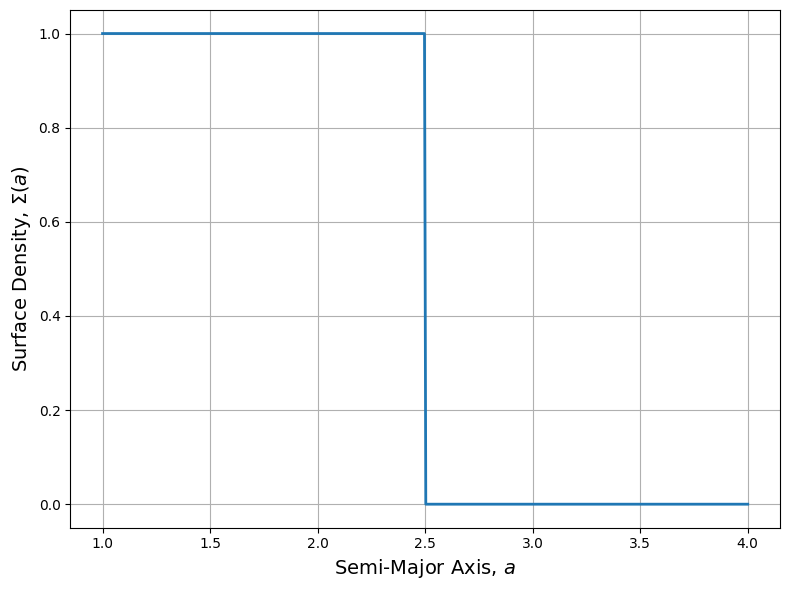

In [10]:
step_down_profile = SigmaA(a_min=1, a_max=4, profile_type='step_down', step=2.5)
step_down_profile.plot()

### Example Code (Manual Plotting)

Of course, the user can choose to return the $\Sigma(a)$ values and plot manually for full control. This is an example showing how to obtain $\Sigma(a)$ profiles using all of the built-in methods and the plotting them together.

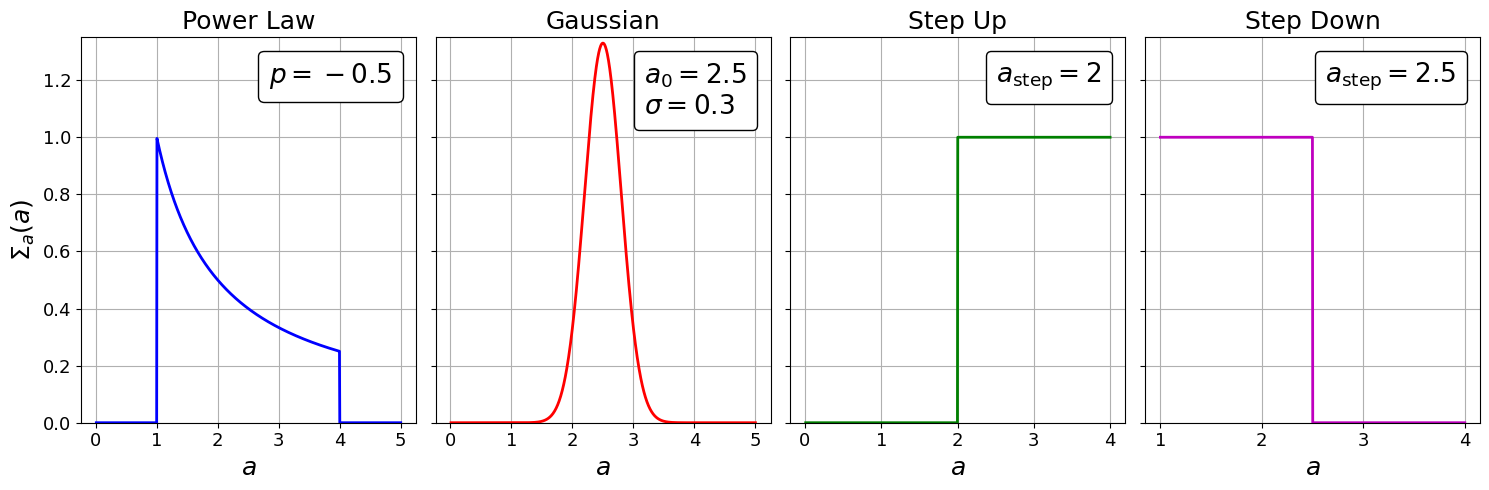

In [11]:
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 5))

a_vals = np.linspace(0.01, 5, 1_000)
a_vals2 = np.linspace(0.01, 4, 1_000)
a_vals3 = np.linspace(1, 4, 1_000)


# Plot data on each subplot
ax1.plot(a_vals, power_law_profile(a_vals), 'b-', lw = 2, 
         label = r"$p = -0.5$")
ax1.set_title('Power Law', fontsize = 18)
ax1.set_xlabel(r'$a$', fontsize = 18)
ax1.set_ylabel(r'$\Sigma_a(a)$', fontsize = 18)

ax2.plot(a_vals, gaussian_profile(a_vals), 'r-', lw = 2, 
         label = r"$a_0 = 2.5$" + "\n" + r"$\sigma = 0.3$")
ax2.set_title('Gaussian', fontsize = 18)
ax2.set_xlabel(r'$a$', fontsize = 18)

ax3.plot(a_vals2, step_up_profile(a_vals2), 'g-', lw = 2, 
         label = r"$a_\mathrm{step} = 2$")
ax3.set_title('Step Up', fontsize = 18)
ax3.set_xlabel(r'$a$', fontsize = 18)

ax4.plot(a_vals3, step_down_profile(a_vals3), 'm-', lw = 2, 
         label = r"$a_\mathrm{step} = 2.5$")
ax4.set_title('Step Down', fontsize = 18)
ax4.set_xlabel(r'$a$', fontsize = 18)


for ax in (ax1, ax2, ax3, ax4):
    ax.set_ylim(0, 1.35)
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.legend(fontsize = 19, loc = 'upper right', framealpha=1.0, 
              edgecolor='black', handlelength=0, handletextpad=0)
    ax.grid()

for ax in (ax2, ax3, ax4):
    ax.set_yticklabels([])

plt.tight_layout()


## Using a Custom Profile Type

The `SigmaA` class can be initialised with any user-supplied function. 

**Note**: The supplied function should be vectorised, and be provided in such a way that the semi-major axis, $a$, is the only parameter. This can be done by wrapping the function manually or using a `lambda` function.

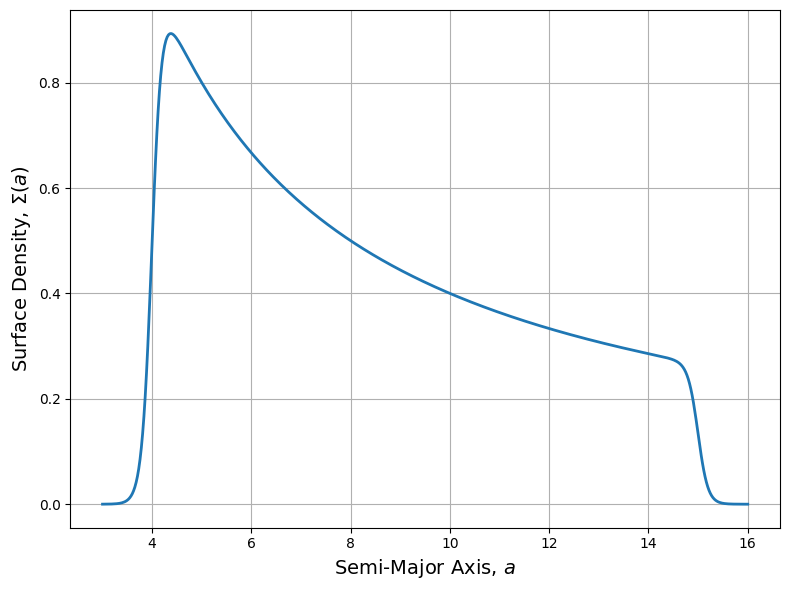

In [12]:
# Define the custom profile
def sig_a_smooth(a, *pars):
    plaw = pars[0] 
    sigma0 = pars[1] 
    a_in = pars[2] 
    a_out  = pars[3] 
    w_in = pars[4] 
    w_out = pars[5] 
        
    f_1 = sigma0*(a_in/a)**plaw
    f_2 = 0.5*(1.0+np.tanh((a-a_in)/w_in))
    f_3 = 0.5*(1.0+np.tanh((a_out-a)/w_out))

    return f_1*f_2*f_3

parameters = [1.0, 1.0, 4.0, 15.0, 0.2, 0.2]

# Initialise the class
custom_profile = SigmaA(a_min=3, a_max=16, profile_type = 'custom', 
                        sigma_func = lambda a: sig_a_smooth(a, *parameters))
custom_profile.plot()